# Conv1d 기반 TextCNN 텍스트 분류

TextCNN은 문장의 임베딩 행렬 위에서 여러 크기의 1차원 합성곱 필터를 움직여 짧은 지역 표현을 찾는 텍스트 분류 모델이다. 커널 크기 2는 두 토큰, 크기 3은 세 토큰처럼 서로 다른 길이의 패턴을 학습한다.

LSTM이 토큰을 순서대로 처리하는 것과 달리 TextCNN은 여러 위치의 지역 표현을 병렬로 계산할 수 있다. 감성 분류, 의도 분류처럼 `정말 재미`, `전개가 너무 느리다` 같은 짧은 표현이 중요한 문제에서 빠른 기준 신경망으로 사용할 수 있다.

## 01. TextCNN의 지역 표현

합성곱 커널은 임베딩 행렬의 연속된 토큰 위치를 한 번에 본다. 커널 크기 2·3·4는 각각 2-gram·3-gram·4-gram 길이의 지역 표현을 찾지만, 단순 빈도를 세는 N-gram과 달리 어떤 패턴이 분류에 유용한지를 가중치로 학습한다.

각 필터가 문장의 여러 위치에서 만든 값 중 가장 큰 값만 남기는 연산이 Global Max Pooling이다. 이 결과는 “이 문장 어디엔가 해당 패턴이 강하게 있었는가?”를 나타내며, 세 커널의 결과를 연결해 클래스 로짓을 만든다.


## 02. TextCNN 내부의 텐서 흐름

`nn.Conv1d`는 입력을 `(B, E, L)` 순서로 받기 때문에 임베딩 결과 `(B, L, E)`의 두 번째와 세 번째 축을 바꾼다. 각 커널의 feature map에서 토큰 위치 축의 최댓값을 고르면 필터마다 값 하나가 남는다.

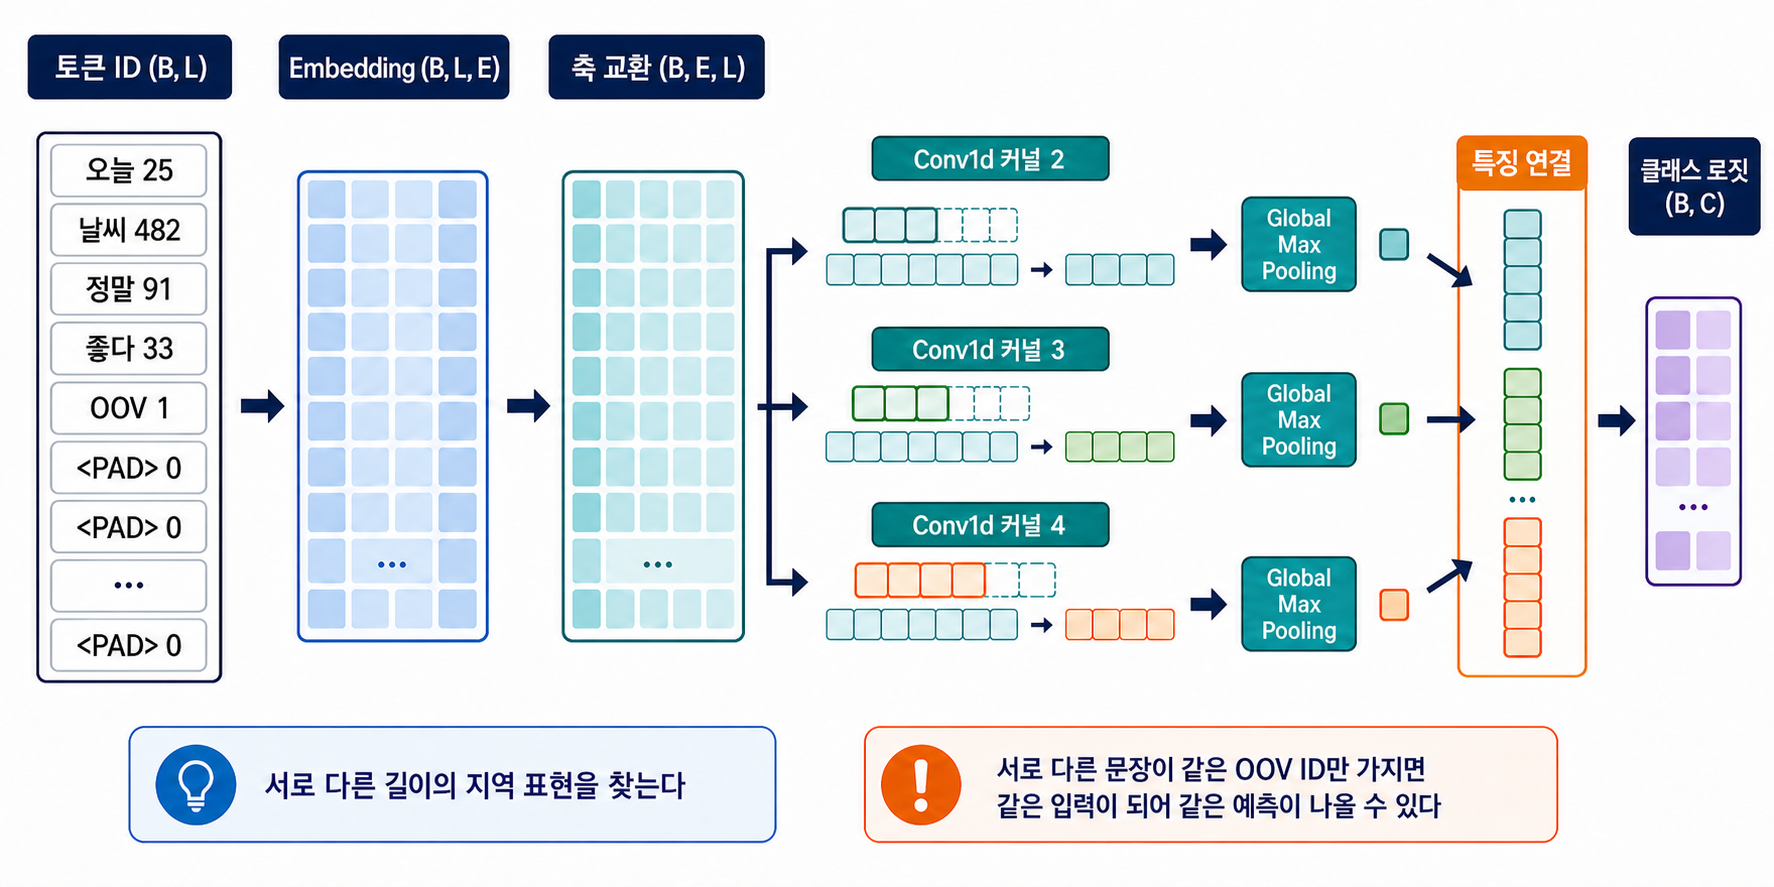


### 재현 가능한 수업용 감성 문장 만들기

여덟 개 주어와 긍정·부정 표현을 조합해 96개 문장을 만든다. 같은 감성 단서가 여러 주어와 함께 나타나므로 TextCNN이 짧은 표현을 학습하는 흐름을 빠르게 확인할 수 있다.

이 데이터는 의도적으로 쉬운 합성 예제이다. 테스트 점수가 높더라도 실제 영화 리뷰의 반어, 오타와 긴 문맥을 해결했다고 해석하지 않는다.


In [1]:
import random
from collections import Counter
from importlib.metadata import version

import numpy as np
import torch
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cpu")

subjects = ["영화", "드라마", "작품", "이야기", "연출", "배우", "결말", "장면"] # 8개
positive_templates = [                                   # 긍정 문장 6개
    "{subject} 정말 재미 있고 감동 깊다",
    "{subject} 매우 훌륭 하고 만족 스럽다",
    "{subject} 분위기 따뜻 하고 추천 한다",
    "{subject} 전개 빠르고 몰입 잘 된다",
    "{subject} 신선 하고 다시 보고 싶다",
    "{subject} 매력 있고 음악 좋다",
]
negative_templates = [                                   # 부정 문장 6개
    "{subject} 정말 지루 하고 실망 크다",
    "{subject} 매우 형편없고 최악 이다",
    "{subject} 분위기 불쾌 하고 비추천 한다",
    "{subject} 전개 느리고 몰입 안 된다",
    "{subject} 뻔하고 다시 보고 싶지 않다",
    "{subject} 매력 없고 음악 나쁘다",
]

texts = []
labels = []

# 같은 subject마다 긍정 6개와 부정 6개를 함께 생성한다.  --> 총 96개 조합 가능.
# 1==긍정, 0==부정.
for subject in subjects:
    for template in positive_templates:
        texts.append(template.format(subject=subject))  # 문장 + subject 조합
        labels.append(1)
    for template in negative_templates:
        texts.append(template.format(subject=subject))
        labels.append(0)

print("문장 수:", len(texts))
print("클래스별 문장 수:", np.bincount(labels).tolist())
print("긍정 예:", texts[0])
print("부정 예:", texts[6])

문장 수: 96
클래스별 문장 수: [48, 48]
긍정 예: 영화 정말 재미 있고 감동 깊다
부정 예: 영화 정말 지루 하고 실망 크다


### 학습·검증·테스트 분리와 토큰 ID 변환

학습 데이터로 어휘를 만들고 `PAD=0`, `OOV=1`을 예약한다. 문장은 최대 8개 토큰으로 맞추며 결과 shape `(문장 수, 8)`의 각 행이 한 문장이다.

검증 데이터는 epoch별 학습 상태를 확인하고, 테스트 데이터는 학습이 끝난 뒤 성능을 확인한다.


In [2]:
all_indices = np.arange(len(texts))
# 클래스 비율을 유지하며 최종 테스트 인덱스를 먼저 분리한다.
train_indices, test_indices = train_test_split(
    all_indices,
    test_size=20,
    random_state=SEED,
    stratify=labels,
)
# 남은 인덱스에서도 비율을 유지해 검증 인덱스를 나눈다.
train_indices, validation_indices = train_test_split(
    train_indices,
    test_size=16,
    random_state=SEED,
    stratify=[labels[index] for index in train_indices],
)

# 학습 문장만 사용해 토큰 빈도를 세어 평가 누수를 막는다.
token_counts = Counter(
    token
    for index in train_indices
    for token in texts[index].split()
)
vocabulary = {"<PAD>": 0, "<OOV>": 1}
for token, _ in token_counts.most_common():
    vocabulary[token] = len(vocabulary)

MAX_LENGTH = 8


def encode_sentence(sentence):
    """한 문장을 앞 8개 토큰 ID와 오른쪽 PAD로 구성된 길이 8 목록으로 변환한다."""
    # 토큰을 최대 8개 ID로 바꾸고 미등록 토큰은 OOV로 처리한다.
    token_ids = [
        vocabulary.get(token, vocabulary["<OOV>"])
        for token in sentence.split()[:MAX_LENGTH]
    ]
    # 오른쪽 PAD를 붙여 모든 입력 길이를 8로 맞춘다.
    return token_ids + [vocabulary["<PAD>"]] * (MAX_LENGTH - len(token_ids))


def encode_indices(indices):
    """원본 문장 인덱스를 `(문장 수, 8)` torch.long 토큰 ID 텐서로 변환한다."""
    encoded_rows = [encode_sentence(texts[index]) for index in indices]
    # 문장별 ID 목록을 Embedding 입력용 long 텐서로 쌓는다.
    return torch.tensor(encoded_rows, dtype=torch.long)


# 같은 원본 인덱스로 입력 토큰과 정답 레이블을 맞춰 텐서화한다.
X_train = encode_indices(train_indices)
X_validation = encode_indices(validation_indices)
X_test = encode_indices(test_indices)
y_train = torch.tensor([labels[index] for index in train_indices], dtype=torch.long)
y_validation = torch.tensor(
    [labels[index] for index in validation_indices],
    dtype=torch.long,
)
y_test = torch.tensor([labels[index] for index in test_indices], dtype=torch.long)

print("어휘 크기:", len(vocabulary))
print("데이터 shape:", tuple(X_train.shape), tuple(X_validation.shape), tuple(X_test.shape))
print("첫 학습 문장 ID:", X_train[0].tolist())



어휘 크기: 51
데이터 shape: (60, 8) (16, 8) (20, 8)
첫 학습 문장 ID: [20, 36, 2, 15, 16, 37, 0, 0]


### 병렬 합성곱과 Global Max Pooling 모델

임베딩 차원은 24이고 각 커널은 16개의 필터를 가진다. 세 커널의 pooling 결과를 연결하면 문장마다 `16 × 3 = 48`개의 특징이 된다. 마지막 선형 계층이 이를 부정·긍정 두 클래스 로짓으로 바꾼다.


In [3]:
EMBEDDING_DIM = 24
# 각 커널은 서로 다른 16개 지역 특징(feature)을 학습한다.
FILTER_COUNT = 16
# 연속된 2·3·4개 토큰 패턴을 병렬로 본다.
KERNEL_SIZES = (2, 3, 4)
# 부정·긍정 두 클래스 로짓을 출력한다.
NUM_CLASSES = 2


class TextCNNClassifier(nn.Module):
    """`(B, L)` 토큰 ID를 받아 `(B, 2)` 감성 로짓을 반환한다."""

    def __init__(self, vocab_size):
        super().__init__()
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=EMBEDDING_DIM,
            padding_idx=0,
        )

        # ModuleList: 여러 Python 계층을 목록처럼 보관하고, 보관된 계층들을 모델 학습 대상으로 등록하는 객체
        # ModuleList는 세 Conv1d 계층을 모델의 학습 파라미터로 등록한다.
        # -> 커널 사이즈 2, 3, 4인 CNN이 하나씩 만들어짐
        self.convolutions = nn.ModuleList(
            [
                nn.Conv1d(
                    # 임베딩 24채널에서 커널마다 16개 지역 특징을 만든다.
                    in_channels=EMBEDDING_DIM,
                    out_channels=FILTER_COUNT,
                    kernel_size=kernel_size,
                )
                for kernel_size in KERNEL_SIZES
            ]
        )

        # train 모드에서 featur를 20% 확률로 0으로 변경
        self.dropout = nn.Dropout(0.2)
        self.classifier = nn.Linear(
            FILTER_COUNT * len(KERNEL_SIZES), # 48개
            NUM_CLASSES, # 2개
        )

    def forward(self, input_ids):
        # (B, L) 토큰 ID를 (B, L, E) 임베딩으로 변환한다.
        embedded = self.embedding(input_ids)
        # Conv1d 입력에 맞게 (B, E, L) 순서로 축을 바꾼다.
        convolution_input = embedded.transpose(1, 2)

        pooled_features = []
        for convolution in self.convolutions:
            # 각 커널이 만든 지역 특징에 ReLU를 적용한다.
            # CNN 결과: (B, 16, L-K+1) L=토큰수, K=커널사이즈
            feature_map = torch.relu(convolution(convolution_input))
            # 위치 축 최댓값만 남겨 커널별 (B, 필터 수) 벡터를 만든다.

            # 각 커널 필터가 어느 위치에서 가장 강하게 반응했는지를 남겨 (B, 16)으로 축소
            pooled_features.append(feature_map.amax(dim=2))

        # 커널별 벡터를 특성 축으로 연결해 문장 벡터를 만든다.
        sentence_features = torch.cat(pooled_features, dim=1)
        dropped_features = self.dropout(sentence_features)
        return self.classifier(dropped_features) # (2,) 반환


In [4]:
model = TextCNNClassifier(len(vocabulary)).to(device)

# 샘플 두 개로 모델 내부 단계의 shape를 확인한다.
sample_inputs = X_train[:2].to(device)
with torch.no_grad():
    sample_embedding = model.embedding(sample_inputs)
    # Embedding의 (B, L, E)를 Conv1d 입력 (B, E, L)로 바꾼다.
    sample_conv_input = sample_embedding.transpose(1, 2)
    # 커널 2·3·4의 위치 축 크기를 실제 출력 shape로 확인한다.
    sample_feature_maps = [
        convolution(sample_conv_input)
        for convolution in model.convolutions
    ]
    sample_logits = model(sample_inputs)

print("토큰 ID:", tuple(sample_inputs.shape))
print("Embedding:", tuple(sample_embedding.shape))
print("Conv1d 입력:", tuple(sample_conv_input.shape))
print("커널별 feature map:", [tuple(item.shape) for item in sample_feature_maps])
print("클래스 로짓:", tuple(sample_logits.shape))


토큰 ID: (2, 8)
Embedding: (2, 8, 24)
Conv1d 입력: (2, 24, 8)
커널별 feature map: [(2, 16, 7), (2, 16, 6), (2, 16, 5)]
클래스 로짓: (2, 2)


### TextCNN 학습과 validation 성능 확인

`CrossEntropyLoss`로 부정·긍정 로짓과 정답 ID의 차이를 계산하고, Adam으로 Embedding·Conv1d·분류 계층의 가중치를 함께 갱신한다.

학습 중에는 train loss가 감소하는지와 validation accuracy가 개선되는지를 확인한다. 최빈 클래스 기준선과 test 성능의 최종 비교는 다음 절에서 수행한다.

다음 코드셀은 학습 코드를 작성하는 의도적 빈칸이다. TextCNN 학습을 완성한 뒤 테스트·도전 문장 평가를 실행한다.

In [5]:
BATCH_SIZE = 16
train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=BATCH_SIZE,
    shuffle=True,
)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)
EPOCHS = 15

for epoch in range(1, EPOCHS + 1):
    # train 모드는 dropout을 활성화해 매 배치의 결합 특성 일부를 임시로 가린다.
    model.train()
    loss_sum = 0.0

    for batch_inputs, batch_labels in train_loader:
        # batch_inputs shape는 `(B, 8)`, batch_labels shape는 `(B,)`이다.
        batch_inputs = batch_inputs.to(device)
        batch_labels = batch_labels.to(device)

        # 이전 배치 기울기를 지우지 않으면 PyTorch가 새 기울기를 누적하므로 역전파 전에 초기화한다.
        optimizer.zero_grad()
        logits = model(batch_inputs)
        loss = criterion(logits, batch_labels)

        loss.backward()
        optimizer.step()
        # 배치 평균 손실에 실제 배치 크기를 곱해 epoch 전체 60건의 손실 합으로 누적한다.
        loss_sum += loss.item() * batch_labels.size(0)


    if epoch in {1, 5, 10, 15}:
        # eval은 dropout을 끄고 no_grad는 평가 연산 그래프와 기울기 저장을 막는다.
        model.eval()
        with torch.no_grad():
            validation_logits = model(X_validation.to(device))
            # argmax(dim=1)은 각 `(부정, 긍정)` 로짓 행에서 큰 열 번호를 예측 ID로 선택한다.
            validation_predictions = validation_logits.argmax(dim=1).cpu()
        validation_accuracy = accuracy_score(
            y_validation,
            validation_predictions,
        )
        # 누적한 샘플별 손실 합을 train 60건으로 나눠 epoch 평균을 계산한다.
        train_loss = loss_sum / len(train_loader.dataset)
        print(
            f"epoch {epoch:02d} | "
            f"train loss {train_loss:.4f} | "
            f"validation accuracy {validation_accuracy:.3f}"
        )

epoch 01 | train loss 0.6736 | validation accuracy 0.938
epoch 05 | train loss 0.0364 | validation accuracy 1.000
epoch 10 | train loss 0.0040 | validation accuracy 1.000
epoch 15 | train loss 0.0015 | validation accuracy 1.000


### 기준선과 비교한 테스트 성능 및 도전 문장

먼저 학습과 같은 생성 규칙의 테스트 데이터에서 기준선을 넘는지 확인한다. 이어서 긍정·부정 표현이 한 문장에 함께 있는 도전 문장을 넣어 TextCNN이 어떤 지역 표현에 더 크게 반응하는지 확률로 읽는다.


In [6]:
model.eval()
with torch.no_grad():
    validation_logits = model(X_validation.to(device))
    # 클래스 축 softmax와 argmax로 확률과 예측 ID를 만든다.
    validation_probabilities = torch.softmax(validation_logits, dim=1).cpu()
    validation_predictions = validation_probabilities.argmax(dim=1)
    test_logits = model(X_test.to(device))
    test_probabilities = torch.softmax(test_logits, dim=1).cpu()
    test_predictions = test_probabilities.argmax(dim=1)

# 불일치 위치를 1차원 Python 인덱스로 변환한다.
validation_wrong_positions = torch.nonzero(
    validation_predictions != y_validation,
).flatten().tolist()
preview_positions = list(range(min(2, len(validation_indices))))
if validation_wrong_positions:
    preview_positions.append(validation_wrong_positions[0])
preview_positions = list(dict.fromkeys(preview_positions))

print("검증 예문별 확률:")
for position in preview_positions:
    # 검증 행 위치를 원본 문장 인덱스로 되돌린다.
    source_index = validation_indices[position]
    answer = "긍정" if y_validation[position].item() == 1 else "부정"
    prediction = "긍정" if validation_predictions[position].item() == 1 else "부정"
    probability = validation_probabilities[position]
    print(
        f"  {texts[source_index]!r} → 정답={answer}, 예측={prediction} "
        f"(부정={probability[0]:.3f}, 긍정={probability[1]:.3f})"
    )
print(
    "검증 오분류:",
    len(validation_wrong_positions),
    "/",
    len(validation_indices),
)
print()

# 기준선·accuracy·F1을 같은 테스트 정답으로 비교한다.
baseline_accuracy = max(np.bincount(y_train.numpy())) / len(y_train)
test_accuracy = accuracy_score(y_test, test_predictions)
test_f1 = f1_score(y_test, test_predictions)

print(f"최빈 클래스 기준선 accuracy: {baseline_accuracy:.3f}")
print(f"TextCNN test accuracy: {test_accuracy:.3f}")
print(f"TextCNN test F1: {test_f1:.3f}")

challenge_texts = [
    "연기 좋지만 이야기 정말 지루 하다",
    "전개 느리지만 마지막 장면 감동 깊다",
    "영상 아름답지만 결말 매우 최악 이다",
    "처음 지루하지만 나중에 정말 재미 있다",
]
challenge_labels = [0, 1, 0, 1]
# 도전 문장도 같은 토큰 ID 변환을 거쳐 모델에 넣는다.
challenge_ids = torch.tensor(
    [encode_sentence(text) for text in challenge_texts],
    dtype=torch.long,
)

with torch.no_grad():
    challenge_logits = model(challenge_ids.to(device))
    challenge_probabilities = torch.softmax(challenge_logits, dim=1).cpu()

challenge_wrong_count = 0
for text, answer, probability in zip(
    challenge_texts,
    challenge_labels,
    challenge_probabilities,
):
    # 각 확률 행의 argmax를 최종 감성 ID로 선택한다.
    prediction = probability.argmax().item()
    answer_label = "긍정" if answer == 1 else "부정"
    predicted_label = "긍정" if prediction == 1 else "부정"
    challenge_wrong_count += int(answer != prediction)
    print(
        f"\n{text!r} → 정답={answer_label}, 예측={predicted_label} "
        f"(부정={probability[0]:.3f}, 긍정={probability[1]:.3f})"
    )

print("\n도전 문장 오분류:", challenge_wrong_count, "/", len(challenge_texts))



검증 예문별 확률:
  '이야기 매력 있고 음악 좋다' → 정답=긍정, 예측=긍정 (부정=0.001, 긍정=0.999)
  '배우 뻔하고 다시 보고 싶지 않다' → 정답=부정, 예측=부정 (부정=0.999, 긍정=0.001)
검증 오분류: 0 / 16

최빈 클래스 기준선 accuracy: 0.500
TextCNN test accuracy: 1.000
TextCNN test F1: 1.000

'연기 좋지만 이야기 정말 지루 하다' → 정답=부정, 예측=부정 (부정=0.992, 긍정=0.008)

'전개 느리지만 마지막 장면 감동 깊다' → 정답=긍정, 예측=긍정 (부정=0.047, 긍정=0.953)

'영상 아름답지만 결말 매우 최악 이다' → 정답=부정, 예측=부정 (부정=0.975, 긍정=0.025)

'처음 지루하지만 나중에 정말 재미 있다' → 정답=긍정, 예측=부정 (부정=0.877, 긍정=0.123)

도전 문장 오분류: 1 / 4


### 서로 다른 문장이 같은 OOV 입력이 되는 한계

학습 어휘에 전혀 없는 두 문장을 같은 길이로 입력하면 모든 새 단어가 OOV ID `1`로 바뀐다. 두 ID 행이 같으면 임베딩부터 이후 계산까지 완전히 같으므로 모델은 원문이 달라도 같은 확률을 반환할 수밖에 없다.


In [7]:
oov_texts = ["웅장한 촬영미", "황홀한 연출미"]
# 서로 다른 OOV 문장을 같은 OOV/PAD 길이로 인코딩한다.
oov_ids = torch.tensor(
    [encode_sentence(text) for text in oov_texts],
    dtype=torch.long,
)

with torch.no_grad():
    oov_logits = model(oov_ids.to(device))
    # 클래스 축 softmax로 두 문장의 예측확률을 비교한다.
    oov_probabilities = torch.softmax(oov_logits, dim=1).cpu()

print("첫 문장 ID:", oov_ids[0].tolist())
print("둘째 문장 ID:", oov_ids[1].tolist())
print("ID 행이 같은가:", torch.equal(oov_ids[0], oov_ids[1]))
print("예측확률이 같은가:", torch.allclose(oov_probabilities[0], oov_probabilities[1]))
print("첫 문장 확률:", oov_probabilities[0].tolist())
print("둘째 문장 확률:", oov_probabilities[1].tolist())



첫 문장 ID: [1, 1, 0, 0, 0, 0, 0, 0]
둘째 문장 ID: [1, 1, 0, 0, 0, 0, 0, 0]
ID 행이 같은가: True
예측확률이 같은가: True
첫 문장 확률: [0.6637147665023804, 0.33628523349761963]
둘째 문장 확률: [0.6637147665023804, 0.33628523349761963]


## 정리와 한계

CNN은 문장에서 `정말 재미`, `매우 지루하다`처럼 **분류에 중요한 도드라지고 짧은 표현**을 자동으로 학습한다. 여러 크기의 커널을 사용해 다양한 길이의 표현을 찾고, Global Max Pooling으로 가장 중요한 특징을 선택한다. RNN과 달리 여러 위치를 병렬로 처리하여 학습과 추론이 빠르지만, 긴 문맥이나 복잡한 문장 관계를 이해하는 데에는 한계가 있다.

TextCNN은 `토큰 ID → 임베딩 → 병렬 Conv1d → Global Max Pooling → 클래스 로짓`으로 문장을 분류한다. 이번 실습에서 중요한 결과는 학습 손실이 감소하고 기준선을 넘은 점, 그리고 지역 표현과 OOV가 실제 예측에 어떤 영향을 주었는지 설명할 수 있다는 점이다.

합성 데이터는 반어, 긴 거리 의존성과 실제 오탈자를 거의 포함하지 않는다. 실제 리뷰 분류에서는 독립된 대규모 데이터와 형태소·서브워드 토큰화, validation 기반 모델 선택과 오류 분석이 필요하다.
